# Iteration 2 — grain-preserving crop

Same `BaselineCNN`, same training config. The **only** change vs. `01_baseline.ipynb`:
the data pipeline uses `build_dataloaders(augment=True)`, which replaces the
"squish to 256x256" resize with `Resize(short side -> 256)` + crop
(RandomCrop for train, CenterCrop for val/test).

Goal: keep fine grain intact so the **noise** class has a signal to learn, and get
free augmentation against the mild overfitting seen in the baseline.

Baseline to beat: **val macro-F1 0.853 (all) / 0.530 (combo)**.
Test split is not touched here.

In [1]:
import os
from pathlib import Path

if Path.cwd().name == "notebooks":
    os.chdir("..")
print("working dir:", Path.cwd())

import sys
sys.path.append("src")

import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from dataset import build_dataloaders
from model import BaselineCNN
from metrics import (evaluate_model, compute_metrics, print_metrics,
                     combo_mask, DEFECT_COLUMNS)

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

working dir: c:\Users\Shamik\Desktop\ImageQuality_Classifier\ImageQuality_Classifier
device: cuda


## 1. Data — crop pipeline (`augment=True`)

In [2]:
loaders = build_dataloaders(batch_size=32, augment=True)   # <-- the only change from the baseline
for name, ldr in loaders.items():
    print(f"{name:5s} {len(ldr.dataset):5d} images | {len(ldr):3d} batches")

train  3150 images |  99 batches
val     722 images |  23 batches
test    728 images |  23 batches


## 2. Model, loss, optimizer

Identical to the baseline: `BaselineCNN`, `BCEWithLogitsLoss`, `Adam(lr=1e-3)`.

In [3]:
model = BaselineCNN().to(device)
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

print(f"{sum(p.numel() for p in model.parameters()):,} parameters")

8,777,797 parameters


## 3. Training helpers (unchanged)

In [4]:
def train_one_epoch(model, loader, criterion, optimizer, device):
    """One full pass over the training data. Returns the average training loss."""
    model.train()
    running_loss, n_batches = 0.0, 0

    for images, labels in loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        n_batches += 1

    return running_loss / n_batches

## 4. The epoch loop

In [5]:
NUM_EPOCHS = 10
CKPT_PATH = Path("models/crop_best.pt")
CKPT_PATH.parent.mkdir(exist_ok=True)

history = []
best_val_f1 = -1.0

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss = train_one_epoch(model, loaders["train"], criterion, optimizer, device)

    y_true, y_prob, val_loss = evaluate_model(model, loaders["val"], device, criterion)
    vm = compute_metrics(y_true, y_prob)
    val_f1 = vm["macro_f1"]

    row = {"epoch": epoch, "train_loss": train_loss, "val_loss": val_loss,
           "val_macro_f1": val_f1}
    for c in DEFECT_COLUMNS:
        row[f"f1_{c}"] = vm["per_class"][c]["f1"]
    history.append(row)

    flag = ""
    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        torch.save(model.state_dict(), CKPT_PATH)
        flag = "  <- saved (best so far)"

    print(f"epoch {epoch:2d} | train_loss {train_loss:.4f} | val_loss {val_loss:.4f} "
          f"| val_macro_f1 {val_f1:.3f}{flag}")

print(f"\nbest val macro-F1: {best_val_f1:.3f}  ->  {CKPT_PATH}")

epoch  1 | train_loss 0.3132 | val_loss 0.2820 | val_macro_f1 0.573  <- saved (best so far)
epoch  2 | train_loss 0.2082 | val_loss 0.2802 | val_macro_f1 0.691  <- saved (best so far)
epoch  3 | train_loss 0.1892 | val_loss 0.3152 | val_macro_f1 0.572
epoch  4 | train_loss 0.1601 | val_loss 0.2162 | val_macro_f1 0.789  <- saved (best so far)
epoch  5 | train_loss 0.1379 | val_loss 0.2039 | val_macro_f1 0.809  <- saved (best so far)
epoch  6 | train_loss 0.1238 | val_loss 0.2546 | val_macro_f1 0.749
epoch  7 | train_loss 0.1124 | val_loss 0.2499 | val_macro_f1 0.829  <- saved (best so far)
epoch  8 | train_loss 0.0945 | val_loss 0.2482 | val_macro_f1 0.811
epoch  9 | train_loss 0.1003 | val_loss 0.2447 | val_macro_f1 0.792
epoch 10 | train_loss 0.0975 | val_loss 0.2347 | val_macro_f1 0.845  <- saved (best so far)

best val macro-F1: 0.845  ->  models\crop_best.pt


In [6]:
hist = pd.DataFrame(history)
hist.to_csv("models/crop_history.csv", index=False)
hist

,epoch,train_loss,val_loss,val_macro_f1,f1_blur,f1_underexposed,f1_overexposed,f1_noise,f1_contrast
0,1,0.313187,0.282009,0.572551,0.351064,0.885714,0.849421,0.000000,0.776557
1,2,0.208238,0.280161,0.690722,0.576923,0.920290,0.737864,0.407143,0.811388
2,3,0.189233,0.315226,0.571800,0.642458,0.906883,0.843373,0.055172,0.411111
3,4,0.160086,0.216150,0.788514,0.765217,0.940239,0.851064,0.533937,0.852113
4,5,0.137863,0.203852,0.808640,0.814815,0.947761,0.819383,0.644444,0.816794
5,6,0.123771,0.254551,0.749079,0.794613,0.957854,0.854093,0.292683,0.846154
6,7,0.112430,0.249950,0.829065,0.793103,0.911877,0.865546,0.737589,0.837209
7,8,0.094515,0.248168,0.810590,0.808511,0.940239,0.875000,0.672897,0.756303
8,9,0.100282,0.244721,0.791562,0.813278,0.939394,0.839506,0.478261,0.887372
9,10,0.097463,0.234713,0.844528,0.813559,0.953488,0.885609,0.675439,0.894545


## 5. Diagnostics

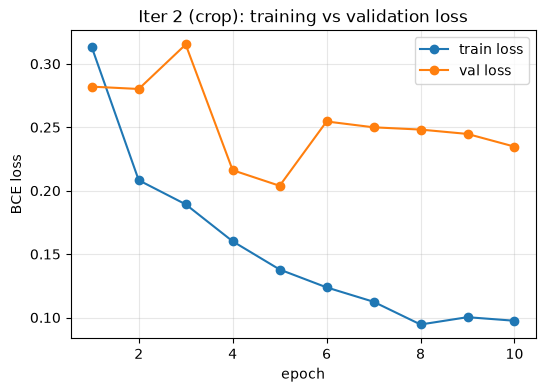

In [7]:
plt.figure(figsize=(6, 4))
plt.plot(hist["epoch"], hist["train_loss"], marker="o", label="train loss")
plt.plot(hist["epoch"], hist["val_loss"], marker="o", label="val loss")
plt.xlabel("epoch"); plt.ylabel("BCE loss"); plt.title("Iter 2 (crop): training vs validation loss")
plt.legend(); plt.grid(alpha=0.3); plt.show()

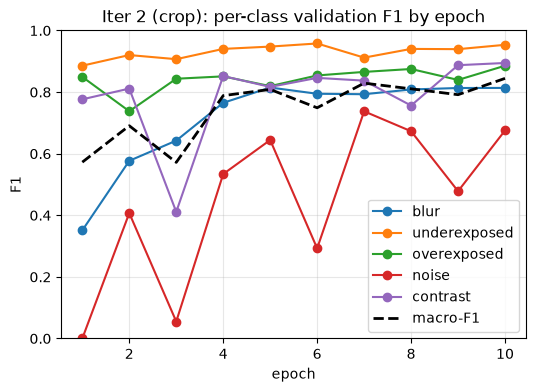

In [8]:
plt.figure(figsize=(6, 4))
for c in DEFECT_COLUMNS:
    plt.plot(hist["epoch"], hist[f"f1_{c}"], marker="o", label=c)
plt.plot(hist["epoch"], hist["val_macro_f1"], "k--", linewidth=2, label="macro-F1")
plt.xlabel("epoch"); plt.ylabel("F1"); plt.title("Iter 2 (crop): per-class validation F1 by epoch")
plt.legend(); plt.grid(alpha=0.3); plt.ylim(0, 1); plt.show()

## 6. Evaluate the best checkpoint on validation

Compare these to the baseline: **0.853 (all) / 0.530 (combo)**, and noise F1 0.70.

In [9]:
best_model = BaselineCNN().to(device)
best_model.load_state_dict(torch.load(CKPT_PATH))

y_true, y_prob, _ = evaluate_model(best_model, loaders["val"], device)

print_metrics(compute_metrics(y_true, y_prob), "ITER2 VAL - all images")

val_files = loaders["val"].dataset.df["filename"].values
mask = combo_mask(val_files)
print_metrics(compute_metrics(y_true[mask], y_prob[mask]),
              f"ITER2 VAL - combo images only (n={int(mask.sum())})")

C:\Users\Shamik\AppData\Local\Temp\ipykernel_32640\1826853248.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(CKPT_PATH))



=== ITER2 VAL - all images ===
macro-F1 0.845 | macro-P 0.919 | macro-R 0.796 | subset-acc 0.799
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            0.990   0.691  0.814   0.931    96     1    43   582
underexposed    0.976   0.932  0.953   0.993   123     3     9   587
overexposed     0.851   0.923  0.886   0.951   120    21    10   571
noise           0.865   0.554  0.675   0.827    77    12    62   571
contrast        0.911   0.879  0.895   0.915   123    12    17   570

=== ITER2 VAL - combo images only (n=50) ===
macro-F1 0.520 | macro-P 0.800 | macro-R 0.409 | subset-acc 0.000
class            prec  recall     f1  pr_auc    tp    fp    fn    tn
blur            1.000   0.185  0.312   0.865     5     0    22    23
underexposed    1.000   0.600  0.750   1.000    12     0     8    30
overexposed     1.000   0.722  0.839   0.997    13     0     5    32
noise           0.000   0.000  0.000   0.914     0     0    27    23
contrast        1.000   0.536  

## 7. FINAL: test set — run once

Only after the whole modeling phase is done. Not now.

In [ ]:
y_true, y_prob, _ = evaluate_model(best_model, loaders["test"], device)

print_metrics(compute_metrics(y_true, y_prob), "ITER2 TEST - all images")

test_files = loaders["test"].dataset.df["filename"].values
mask = combo_mask(test_files)
print_metrics(compute_metrics(y_true[mask], y_prob[mask]),
              f"ITER2 TEST - combo images only (n={int(mask.sum())})")